In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
traindf = pd.read_csv('DiamondPrices.csv')
#read data from csv

In [3]:
traindf
#display table

,id,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,NaN,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,53940,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64
53940,53941,0.71,Premium,E,SI1,60.5,55.0,2756,5.79,5.74,3.49
53941,53942,0.71,Premium,NaN,SI1,59.8,62.0,2756,5.74,5.73,3.43


In [4]:
traindf.columns
#check column names

Index(['id', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price',
       'x', 'y', 'z'],
      dtype='str')

In [5]:
traindf.describe()
#describe table 

,id,carat,depth,table,price,x,y,z
count,53943.000000,51210.000000,51262.000000,51254.000000,53943.000000,51209.000000,51274.000000,51284.000000
mean,26972.000000,0.797648,61.749467,57.461613,3932.734294,5.733212,5.734110,3.538269
std,15572.147122,0.474164,1.431262,2.234639,3989.338447,1.121856,1.144095,0.706337
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13486.500000,0.400000,61.000000,56.000000,950.000000,4.720000,4.720000,2.910000
50%,26972.000000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.520000
75%,40457.500000,1.040000,62.500000,59.000000,5324.000000,6.540000,6.540000,4.030000
max,53943.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [6]:
traindf = traindf.drop(columns = 'id')
#drop unused column
traindf.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='str')

In [7]:
traindf = traindf[(traindf['x'] > 0) & (traindf['y'] > 0) & (traindf['z'] > 0)]
#remove rows where x = 0 , y = 0 ,z = 0 and nan

In [8]:
# Remove outliers using percentiles
for col in ['x', 'y', 'z']:
    lower = traindf[col].quantile(0.01)
    upper = traindf[col].quantile(0.99)
    traindf = traindf[(traindf[col] >= lower) & (traindf[col] <= upper)]

In [9]:
traindf.drop_duplicates(keep='first', inplace = True)

In [10]:
traindf.isnull().sum()
#check null value

carat      2211
cut        2204
color      2212
clarity    2157
depth      2158
table      2159
price         0
x             0
y             0
z             0
dtype: int64

In [11]:
traindf.dtypes
#check column types

carat      float64
cut            str
color          str
clarity        str
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

In [12]:
traindf['cut'].unique()

<StringArray>
['Premium', 'Good', 'Ideal', 'Very Good', 'Fair', nan]
Length: 6, dtype: str

In [13]:
traindf['cut'] = traindf['cut'].fillna(traindf['cut'].mode()[0])
traindf['cut'] = traindf['cut'].astype('category')
#fill empty value with mode since its a categorical value

In [14]:
traindf['color'].unique()

<StringArray>
['I', 'J', 'E', 'H', 'D', 'G', 'F', nan]
Length: 8, dtype: str

In [15]:
traindf['color'] = traindf['color'].fillna(traindf['color'].mode()[0])
traindf['color'] = traindf['color'].astype('category')
#fill empty value with mode since its a categorical value

In [16]:
traindf['clarity'].unique()

<StringArray>
['VS2', 'SI2', 'SI1', 'I1', nan, 'VS1', 'VVS1', 'VVS2', 'IF']
Length: 9, dtype: str

In [17]:
traindf['clarity'] = traindf['clarity'].fillna(traindf['clarity'].mode()[0])
traindf['clarity'] = traindf['clarity'].astype('category')
#fill empty value with mode since its a categorical value

In [18]:
traindf['depth'].skew()
#check skew to see if there is outlier 

np.float64(-0.13798164996763498)

In [19]:
traindf['depth'] = traindf['depth'].fillna(traindf['depth'].mean())
#fill empty value with mean since its a numerical value 

In [20]:
traindf['carat'] .skew()

np.float64(0.774409401567259)

In [21]:
traindf['carat'] = traindf['carat'].fillna(traindf['carat'].median())
#fill empty value with mean since its a numerical value

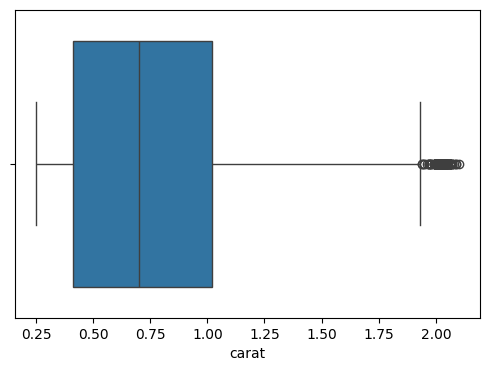

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(x=traindf['carat'])
plt.show()

In [23]:
traindf['carat_log'] = np.log1p(traindf['carat'])
#deal with outlier

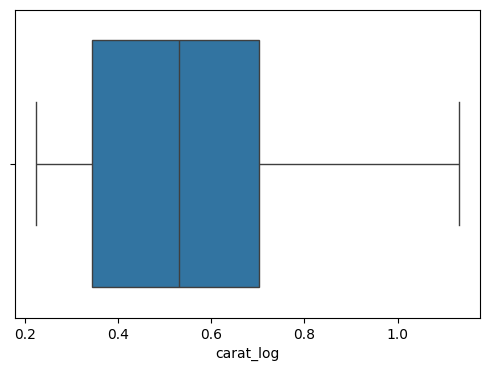

In [24]:
plt.figure(figsize=(6,4))
sns.boxplot(x=traindf['carat_log'])
plt.show()

In [25]:
traindf['carat_log'].skew()

np.float64(0.43530765491609485)

In [26]:
traindf['table'].skew()
#check skew to see if there is outlier 

np.float64(0.734284433898095)

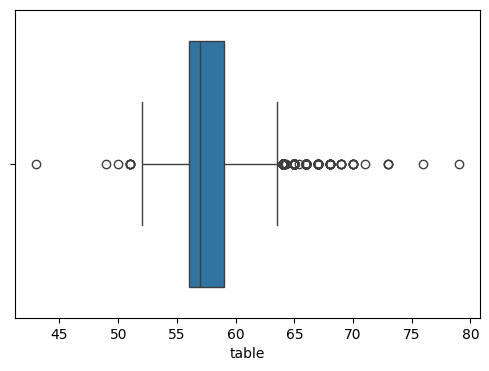

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x=traindf['table'])
plt.show()
#display plot 

In [28]:
traindf['table'] = traindf['table'].fillna(traindf['table'].median())
#fill empty value with median since its a numerical value 

In [29]:
traindf['table_log'] = np.log1p(traindf['table'])
#deal with outlier

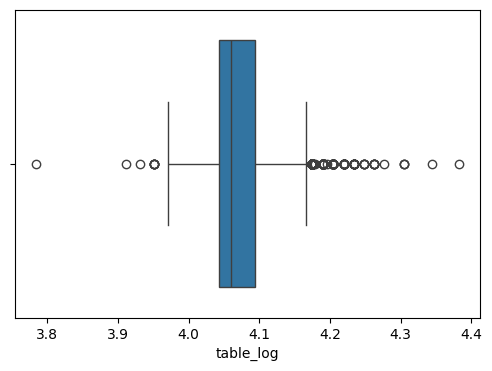

In [30]:
plt.figure(figsize=(6,4))
sns.boxplot(x=traindf['table_log'])
plt.show()

In [31]:
traindf['table_log'].skew()
#check skew to see if there is outlier 

np.float64(0.6224636858310691)

In [32]:
traindf['x'].skew()
#check skew to see if there is outlier 

np.float64(0.26106851179581314)

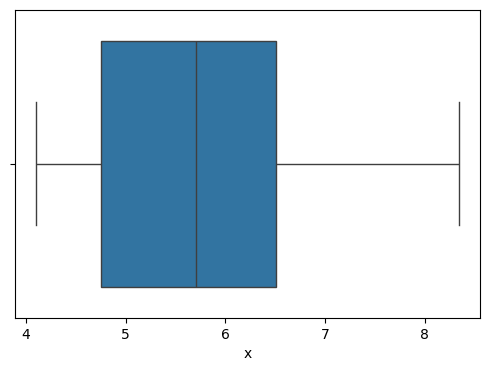

In [33]:
plt.figure(figsize = (6,4))
sns.boxplot(x = traindf['x'])
plt.show()

In [34]:
traindf['y'].skew()

np.float64(0.25512562005519546)

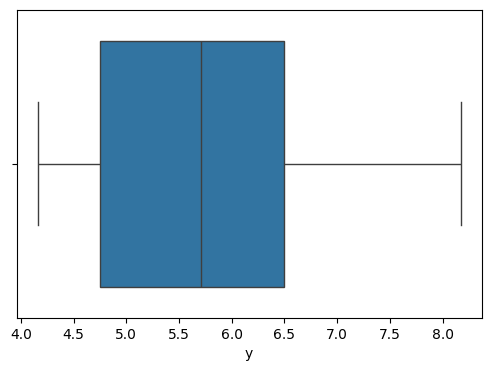

In [35]:
plt.figure(figsize=(6,4))
sns.boxplot(x=traindf['y'])
plt.show()
#plot_y

In [36]:
print(traindf['z'].skew())

0.2541860005337353


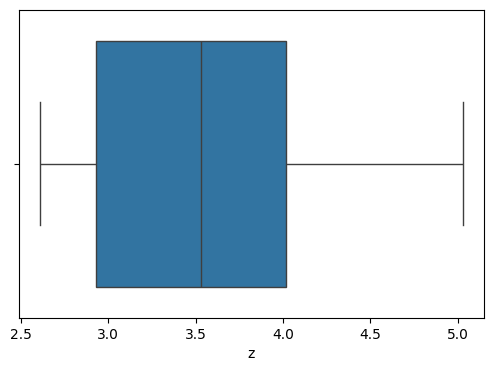

In [37]:
plt.figure(figsize=(6,4))
sns.boxplot(x=traindf['z'])
plt.show()
#plot_z
#check skew to see if there is outlier 

In [38]:
traindf['price'].skew()

np.float64(1.6053670923324694)

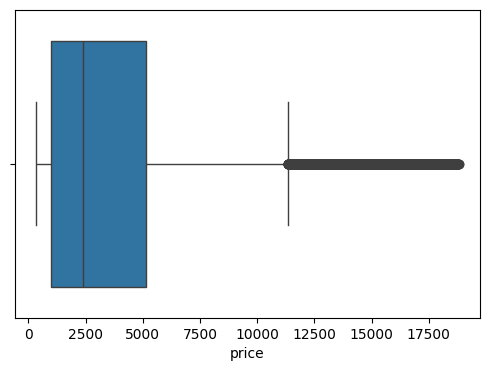

In [39]:
plt.figure(figsize=(6,4))
sns.boxplot(x=traindf['price'])
plt.show()
#display plot 

In [40]:
traindf['price_log'] = np.log1p(traindf['price'])

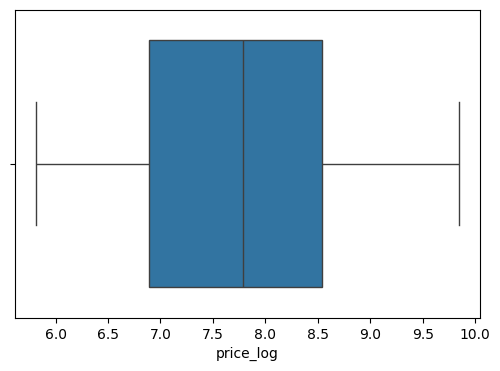

In [41]:
plt.figure(figsize=(6,4))
sns.boxplot(x=traindf['price_log'])
plt.show()
#display plot 

In [42]:
traindf['price_log'].skew()

np.float64(0.08784758852264486)

In [43]:
traindf

,carat,cut,color,clarity,depth,table,price,x,y,z,carat_log,table_log,price_log
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,0.254642,4.077537,5.814131
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,0.270027,4.077537,5.817111
10,0.30,Good,J,SI1,64.0,55.0,339,4.25,4.28,2.73,0.262364,4.025352,5.828946
13,0.31,Ideal,J,SI2,62.2,54.0,344,4.35,4.37,2.71,0.270027,4.007333,5.843544
15,0.32,Premium,E,I1,60.9,58.0,345,4.38,4.42,2.68,0.277632,4.077537,5.846439
...,...,...,...,...,...,...,...,...,...,...,...,...,...
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56,0.530628,4.110874,7.922261
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74,0.620576,4.077537,7.922261
53939,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64,0.559616,4.025352,7.922261
53940,0.71,Premium,E,SI1,60.5,55.0,2756,5.79,5.74,3.49,0.536493,4.025352,7.921898


In [44]:
traindf.isnull().sum()
#check if there are any nulls left

carat        0
cut          0
color        0
clarity      0
depth        0
table        0
price        0
x            0
y            0
z            0
carat_log    0
table_log    0
price_log    0
dtype: int64

In [45]:
traindf.dtypes
#since model used is linear regression , have to turn categorical data into dummy values

carat         float64
cut          category
color        category
clarity      category
depth         float64
table         float64
price           int64
x             float64
y             float64
z             float64
carat_log     float64
table_log     float64
price_log     float64
dtype: object

In [46]:
traindfcate = pd.get_dummies(traindf[['color','cut','clarity']],drop_first=True)
#turn categorical data in dummy values

In [47]:
trainscaledpands = traindf[['carat_log','depth','table_log','x' ,'y' ,'z' ]]
#add all numerical data into thier own dataframe

In [48]:
trainingset = pd.concat([trainscaledpands,traindfcate], axis=1)
#combine the dummy values and the numerical data

In [49]:
x_train, x_test, y_train, y_test = train_test_split(
    trainingset, traindf['price_log'],
    test_size=0.2,      # 20% for testing
    random_state=13     # ensures same split every run
)
#create a training and testing data set at a 4 : 1  ratio respectively and seeding the rng so that the result is alwyas the same

In [50]:
from sklearn.feature_selection import f_regression

f_values, p_values = f_regression(x_train, y_train)

results = pd.DataFrame({
    "Feature": x_train.columns,
    "F_value": f_values,
    "p_value": p_values
})

print(results)

#try removing cut_Good , color_F , clarity_SI1 
#base R²: 0.9729892582469725
#cut_Good: R²: 0.9729100377618422
#color_F R²: 0.972353653081062
#clarity_SI1 R²: 0.9685245376176672



          Feature        F_value        p_value
0       carat_log  224533.818588   0.000000e+00
1           depth      10.509157   1.188960e-03
2       table_log    1014.432784  1.856781e-219
3               x  410038.270649   0.000000e+00
4               y  418967.170861   0.000000e+00
5               z  376138.757312   0.000000e+00
6         color_E     142.888008   7.211797e-33
7         color_F       5.830416   1.575651e-02
8         color_G       1.235930   2.662645e-01
9         color_H      56.617105   5.422334e-14
10        color_I      48.067082   4.190475e-12
11        color_J      94.720891   2.340764e-22
12       cut_Good       8.016470   4.638037e-03
13      cut_Ideal     531.448878  1.023704e-116
14    cut_Premium     216.455309   7.521766e-49
15  cut_Very Good      59.838306   1.057459e-14
16     clarity_IF     125.431722   4.590585e-29
17    clarity_SI1      10.633672   1.111536e-03
18    clarity_SI2     477.746711  3.370665e-105
19    clarity_VS1       3.911422   4.796

In [51]:
x_train.columns

Index(['carat_log', 'depth', 'table_log', 'x', 'y', 'z', 'color_E', 'color_F',
       'color_G', 'color_H', 'color_I', 'color_J', 'cut_Good', 'cut_Ideal',
       'cut_Premium', 'cut_Very Good', 'clarity_IF', 'clarity_SI1',
       'clarity_SI2', 'clarity_VS1', 'clarity_VS2', 'clarity_VVS1',
       'clarity_VVS2'],
      dtype='str')

In [52]:
#x_train = x_train.drop(['color_F'] , axis = 1)
#x_test = x_test.drop(['color_F'] , axis = 1)

In [53]:
#x_train = x_train.drop(['cut_Good'], axis=1)
#x_test = x_test.drop(['cut_Good'], axis=1)

In [54]:
#x_train = x_train.drop(['clarity_SI1'], axis=1)
#x_test = x_test.drop(['clarity_SI1'], axis=1)

In [55]:
#x_train.columns

In [56]:
from sklearn.preprocessing import StandardScaler

num_cols = ['carat_log','depth','table_log','x','y','z']

scaler = StandardScaler()
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols]  = scaler.transform(x_test[num_cols])
#scale the numerical data

In [57]:
#check scaled data
print(type(x_train))          # dataframe
print(x_train[num_cols].mean())  # should be ~0
print(x_train[num_cols].std())   # should be ~1 

<class 'pandas.DataFrame'>
carat_log    4.546788e-17
depth        3.095078e-15
table_log   -8.052709e-16
x            4.489699e-16
y            5.863930e-16
z           -8.155674e-16
dtype: float64
carat_log    1.000014
depth        1.000014
table_log    1.000014
x            1.000014
y            1.000014
z            1.000014
dtype: float64


In [58]:
model = LinearRegression()

model.fit(x_train, y_train)
#training model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [59]:
y_pred = model.predict(x_test)
#predict

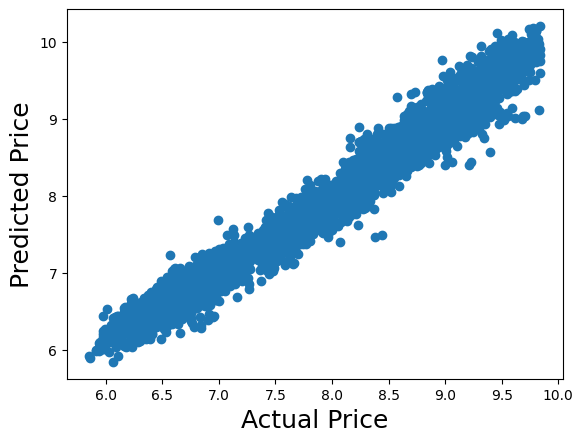

In [60]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual Price',size=18)
plt.ylabel('Predicted Price',size=18)
plt.show()
#plot

In [61]:
r2 = model.score(x_test, (y_test))
print("R²:", r2)
y_pred_m= np.expm1(y_pred)
y_test_m = np.expm1(y_test)
mae = mean_absolute_error(y_test_m, y_pred_m)
print("MAE:", mae)

R²: 0.9729892582469725
MAE: 494.16159079455946


In [62]:
import pickle
pickle.dump(model, open('diamond_model.sav', 'wb'))
pickle.dump(scaler, open('diamond_scaler.sav', 'wb'))

#save model and scaler